In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal

c:\Coding\Python\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class QuadState(TypedDict):
    a:int
    b:int
    c:int

    equation:str
    d:float
    result:str

In [3]:
def equation(state:QuadState)->QuadState:
    equ = f'{state["a"]}x2+{state["b"]}x+{state["c"]}'
    return {'equation': equ}

In [4]:
def calculate_d(state:QuadState)->QuadState:
    d=state['b']**2-4*state['a']*state['c']
    return {"d":d}

In [5]:
def img_root(state:QuadState)->QuadState:

    result = f'No real roots'

    return {'result': result}

In [6]:
def real_root(state: QuadState):

    root1 = (-state["b"] + state["discriminant"]**0.5)/(2*state["a"])
    root2 = (-state["b"] - state["discriminant"]**0.5)/(2*state["a"])

    result = f'The roots are {root1} and {root2}'

    return {'result': result}

In [7]:
def same_root(state:QuadState)->QuadState:

    root = (-state["b"])/(2*state["a"])

    result = f'Only repeating root is {root}'

    return {'result': result}

In [17]:
def check_condition(state: QuadState) -> Literal["Imaginary Roots","Real Roots","Repeated Roots"]:

    if state['d'] > 0:
        return "Real Roots"
    elif state['d'] == 0:
        return "Repeated Roots"
    else:
        return "Imaginary Roots"

In [18]:
graph=StateGraph(QuadState)

graph.add_node("Equation",equation)
graph.add_node("Discriminant",calculate_d)
graph.add_node("Imaginary Roots",img_root)
graph.add_node("Real Roots",real_root)
graph.add_node("Repeated Roots",same_root)

graph.add_edge(START,"Equation")
graph.add_edge("Equation","Discriminant")
graph.add_conditional_edges("Discriminant",check_condition)

graph.add_edge("Imaginary Roots",END)
graph.add_edge("Real Roots",END)
graph.add_edge("Repeated Roots",END)

# workflow=graph.compile()
workflow = graph.compile()

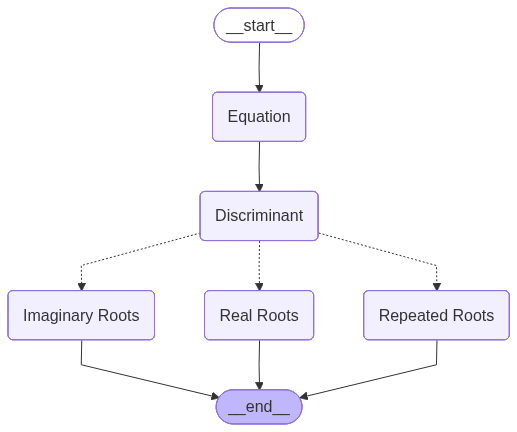

In [20]:
workflow

In [21]:
initial_state={
    'a':2,
    'b':4,
    'c':2
}

workflow.invoke(initial_state)

{'a': 2,
 'b': 4,
 'c': 2,
 'equation': '2x2+4x+2',
 'd': 0,
 'result': 'Only repeating root is -1.0'}